In [1]:
# Cell E — On-demand snapshot: latest Fearnleys weekly T/C values (run any day; updated Wednesdays)
import requests, time
import pandas as pd

GQL = "https://pbrokerapp.hasura.app/v1/graphql"
HEADERS = {"Content-Type": "application/json", "Origin": "https://fearnpulse.com",
           "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/126"}

QUERY = """query Q($routes:[String!],$rateTypes:[String!],$rateSubtypes:[String!],$dateFrom:date,$dateTo:date){
  rate_meta(where:{info:{route:{_in:$routes},rate_type:{_in:$rateTypes},rate_subtype:{_in:$rateSubtypes}},rate_unit:{_eq:"usd"}}){
    rates(where:{date:{_gte:$dateFrom,_lte:$dateTo}},order_by:{date:asc}){date rate}
    info{route rate_type rate_subtype}
  }
}"""

DRY = ["Capesize (180 000 dwt)", "Capesize (182 000 dwt)", "Newcastlemax (208 000 dwt)",
       "Kamsarmax (82 000 dwt)", "Panamax (75 000 dwt)", "Supramax (58 000 dwt)",
       "Ultramax (64 000 dwt)", "Handysize (38 000 dwt)"]
WET = ["VLCC", "Suezmax", "Aframax"]

def fetch(rate_types, rate_subtypes, routes, date_from, date_to):
    body = {"query": QUERY, "variables": {"routes": routes, "rateTypes": rate_types,
            "rateSubtypes": rate_subtypes, "dateFrom": date_from, "dateTo": date_to}}
    for attempt in range(3):
        try:
            r = requests.post(GQL, json=body, headers=HEADERS, timeout=60)
            r.raise_for_status()
            rows = []
            for rm in r.json()["data"]["rate_meta"]:
                for pt in rm["rates"]:
                    rows.append({"date": pt["date"], "route": rm["info"]["route"],
                                 "rate_usd_day": pt["rate"]})
            return pd.DataFrame(rows)
        except Exception as e:
            print(f"  retry {attempt+1}: {str(e)[:100]}"); time.sleep(3)
    return pd.DataFrame()

today = pd.Timestamp.today().normalize()
frm = (today - pd.Timedelta(days=21)).strftime("%Y-%m-%d")
to  = (today + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
raw = pd.concat([fetch(["BULK"], ["TC"], DRY, frm, to),
                 fetch(["TANK"], ["1 Year T/C"], WET, frm, to)], ignore_index=True)
raw["date"] = pd.to_datetime(raw["date"])

rows = []
for route, g in raw.sort_values("date").groupby("route"):
    last2 = g.tail(2)
    cur, prev = last2.iloc[-1], last2.iloc[0]
    chg = cur["rate_usd_day"] - prev["rate_usd_day"]
    rows.append({"route": route, "report_date": cur["date"].date(),
                 "weekday": cur["date"].strftime("%A"),
                 "rate_usd_day": cur["rate_usd_day"], "prev_rate": prev["rate_usd_day"],
                 "chg_usd": chg,
                 "chg_pct": round(chg / prev["rate_usd_day"] * 100, 1) if prev["rate_usd_day"] else None})
snap = pd.DataFrame(rows).sort_values("route").reset_index(drop=True)
print(f"Latest report date available: {snap['report_date'].max()} ({pd.Timestamp(snap['report_date'].max()).strftime('%A')})")
print(snap.to_string(index=False))
snap.to_csv("fearnleys_latest_snapshot.csv", index=False)
print("\nsaved -> fearnleys_latest_snapshot.csv")

Latest report date available: 2026-08-05 (Wednesday)
                     route report_date   weekday  rate_usd_day  prev_rate  chg_usd  chg_pct
                   Aframax  2026-08-05 Wednesday         53500      52500     1000      1.9
    Capesize (180 000 dwt)  2026-08-05 Wednesday         33321      31157     2164      6.9
    Capesize (182 000 dwt)  2026-08-05 Wednesday         36824      34660     2164      6.2
    Handysize (38 000 dwt)  2026-08-05 Wednesday         14500      14500        0      0.0
    Kamsarmax (82 000 dwt)  2026-08-05 Wednesday         20500      19500     1000      5.1
Newcastlemax (208 000 dwt)  2026-08-05 Wednesday         45661      42978     2683      6.2
      Panamax (75 000 dwt)  2026-08-05 Wednesday         18000      17000     1000      5.9
                   Suezmax  2026-08-05 Wednesday         72500      69500     3000      4.3
     Supramax (58 000 dwt)  2026-08-05 Wednesday         17000      16500      500      3.0
     Ultramax (64 000 dwt) 

QA summary (repo vs Fearnleys, full 2021-07 -> repo last row):
                        n_flags  severe  max_abs_pct  total_weeks  share_%
route                                                                     
Supramax (58 000 dwt)       120      17    26.881720          246     48.8
Aframax                     113      18    48.387097          249     45.4
Handysize (38 000 dwt)       60       3    24.812030          133     45.1
Suezmax                     105      15    47.826087          251     41.8
VLCC                         85      34    37.931034          235     36.2
Panamax (75 000 dwt)         88       6    26.701571          246     35.8
Capesize (180 000 dwt)       67       5    21.453333          248     27.0

Top 15 flags by |diff|:
      date   route  repo_rate  fearnleys_rate  rel_diff_pct    severity        direction
2022-03-09 Aframax    15500.0           23000     48.387097 SEVERE >20% Fearnleys higher
2026-03-04 Suezmax    57500.0           85000     47.826087

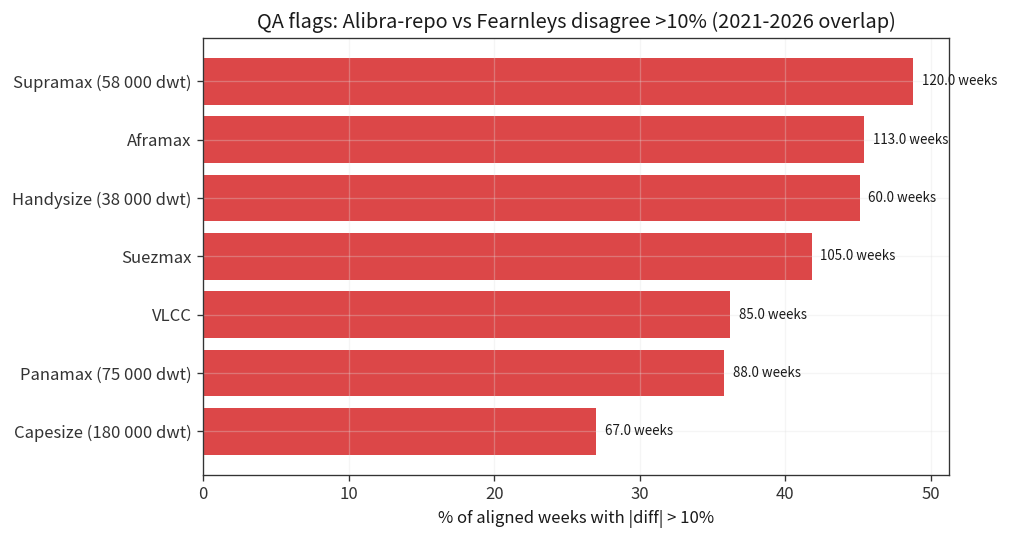

In [2]:
# Cell F — QA report: weeks where repo (Alibra OCR) vs Fearnleys disagree by >10%
# Flags are review candidates: mostly genuine broker disagreement, occasionally OCR errors.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

repo = pd.read_csv("/home/user/shipping_data/time_charter_rates.csv", parse_dates=["date"])
fear = pd.read_csv("fearnleys_tce.csv", parse_dates=["date"])

mapping = {
    "capesize_1y_avg": "Capesize (180 000 dwt)", "panamax_1y_avg": "Panamax (75 000 dwt)",
    "supramax_1y_avg": "Supramax (58 000 dwt)", "handysize_1y_avg": "Handysize (38 000 dwt)",
    "vlcc_1y": "VLCC", "suezmax_1y": "Suezmax", "aframax_1y": "Aframax",
}

def iso_wk(s):
    ic = s.dt.isocalendar()
    return ic["year"].astype(str) + "-W" + ic["week"].astype(str).str.zfill(2)

repo_long = []
for col, route in mapping.items():
    if col not in repo.columns:
        continue
    sub = repo[["date", col]].dropna().copy()
    sub.columns = ["date", "repo_rate"]
    sub["route"] = route
    repo_long.append(sub)
repo_long = pd.concat(repo_long, ignore_index=True)
repo_long["iso_week"] = iso_wk(repo_long["date"])
fear["iso_week"] = iso_wk(fear["date"])

m = repo_long.merge(fear[["iso_week", "route", "rate_usd_day"]], on=["iso_week", "route"], how="inner")
m = m.rename(columns={"rate_usd_day": "fearnleys_rate"})
m["rel_diff_pct"] = (m["fearnleys_rate"] - m["repo_rate"]) / m["repo_rate"] * 100
m["abs_diff_pct"] = m["rel_diff_pct"].abs()
m["direction"] = np.where(m["rel_diff_pct"] > 0, "Fearnleys higher", "Fearnleys lower")
m["severity"] = np.where(m["abs_diff_pct"] > 20, "SEVERE >20%",
                  np.where(m["abs_diff_pct"] > 10, "FLAG >10%", "ok"))

flags = m[m["severity"] != "ok"].copy()

per = flags.groupby("route").agg(n_flags=("route", "size"),
      severe=("severity", lambda s: (s.str.startswith("SEVERE")).sum()),
      max_abs_pct=("abs_diff_pct", "max"))
per["total_weeks"] = m.groupby("route").size()
per["share_%"] = (per["n_flags"] / per["total_weeks"] * 100).round(1)
print("QA summary (repo vs Fearnleys, full 2021-07 -> repo last row):")
print(per.sort_values("share_%", ascending=False).to_string())

print("\nTop 15 flags by |diff|:")
print(flags.nlargest(15, "abs_diff_pct")[["date", "route", "repo_rate", "fearnleys_rate",
      "rel_diff_pct", "severity", "direction"]].to_string(index=False))

flags.to_csv("qa_report_10pct.csv", index=False)
print(f"\nsaved -> qa_report_10pct.csv ({len(flags)} flagged weeks of {len(m)} aligned)")

fig, ax = plt.subplots(figsize=(8.5, 4.6))
d = per.sort_values("share_%")
ax.barh(d.index, d["share_%"], color="#d62728", alpha=0.85)
ax.set_xlabel("% of aligned weeks with |diff| > 10%")
ax.set_title("QA flags: Alibra-repo vs Fearnleys disagree >10% (2021-2026 overlap)")
for i, (idx, row) in enumerate(d.iterrows()):
    ax.text(row["share_%"] + 0.6, i, f"{row['n_flags']} weeks", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("qa_flags_by_route.png", dpi=130)
plt.show()

## Part 9 — What Phase 1 extended (vs the repo's committed data) + new on-demand/QA tooling

**Where data got extended (all from Fearnleys' open GraphQL API, values verified against their published report):**

| Series | Repo had (committed) | Now available (Fearnleys) | Extension |
|---|---|---|---|
| Dry 1-yr T/C (Capesize, Panamax, Supramax) | 2021-07-07 → (n≈250) | **2000-01-05 →** (Capesize n=1,378; Panamax n=1,376; Supramax n=1,146 from 2004) | **+21 years** before repo start |
| Dry 1-yr T/C (Handysize 38k) | 2021-07 → | 2023-10-18 → (n=138) | Fearnleys only tracks it since 2023 — keep Alibra OCR for earlier |
| Dry 1-yr T/C (Newcastlemax, Kamsarmax, Ultramax, Capesize 182k) | — | 2020-03-02 → (n≈323 each; 182k from 2026-02) | **4 new classes** the repo doesn't have |
| Tanker 1-yr T/C (VLCC/Suezmax/Aframax) | 2021-07 → | **2017-07-10 →** (VLCC n=401); Suezmax/Aframax from 2019-02 | **+4 years** before repo start |

**Does it diverge from the repo's Alibra-based data?** Yes — the two are different estimators of the same market: correlation 0.94–0.97 per class over 1,608 aligned weeks (2021–2026), but only ~32% of weeks agree within ±5% and median |diff| is ~8%. Systematic: Fearnleys dry 1-yr runs **3–10% below** Alibra's ATL/PAC average; VLCC runs **~8% above**. Alibra's table is stickier (holds levels for 3–4 weeks), so a "value-nearest" match is often ±1–2 weeks off — genuine broker disagreement, not a date bug. **Rule:** use Fearnleys for pre-2021 extension and as a second opinion with per-class calibration; don't mix raw values into the Alibra series without a provenance tag.

**New tooling on this branch (`phase1-prototype`):**
- **Cell E — on-demand latest snapshot:** run any day; pulls the most recent Fearnleys weekly T/C report (11 routes, current + previous value with weekly change), prints a table and saves `fearnleys_latest_snapshot.csv`. Wednesday cadence: values update Wednesdays.
- **Cell F — QA report:** aligns the repo's committed Alibra CSV with Fearnleys (ISO-week), flags every week where they disagree by **>10%** (severity >20%), prints per-route shares + top-15, saves `qa_report_10pct.csv` and `qa_flags_by_route.png`. Flags are review candidates — mostly broker disagreement, occasionally OCR errors worth a manual look.

**Note on "pushing":** this work lives on notebook branch `phase1-prototype` (main keeps the exploration report). Pushing to the GitHub repo itself needs your credentials — the pattern to promote is: Cell A/E become `scripts/fearnleys_tce.py`, Cell F becomes a QA workflow, then a GitHub Actions cron adds the weekly snapshot (the repo already auto-commits daily).
